In [1]:
# CELDA 1 — Setup y carga de train/test
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Librerías de ML
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

PROJECT_PATH = '/content/drive/MyDrive/HortifrutCostosImport'
PROCESSED_PATH = f'{PROJECT_PATH}/data/processed'
FIGURES_PATH = f'{PROJECT_PATH}/reports/figures'
MODELS_PATH = f'{PROJECT_PATH}/models'
os.makedirs(MODELS_PATH, exist_ok=True)

# Cargar datasets
train = pd.read_parquet(f'{PROCESSED_PATH}/dataset_modelable_train.parquet')
test  = pd.read_parquet(f'{PROCESSED_PATH}/dataset_modelable_test.parquet')

print(f"TRAIN: {train.shape[0]:,} filas × {train.shape[1]} columnas")
print(f"TEST:  {test.shape[0]:,} filas × {test.shape[1]} columnas")
print(f"\nRango temporal train: {train['Fecha_Imputada'].min().date()} → {train['Fecha_Imputada'].max().date()}")
print(f"Rango temporal test:  {test['Fecha_Imputada'].min().date()}  → {test['Fecha_Imputada'].max().date()}")

Mounted at /content/drive
TRAIN: 11,181 filas × 79 columnas
TEST:  3,479 filas × 79 columnas

Rango temporal train: 2020-07-01 → 2024-12-31
Rango temporal test:  2025-01-01  → 2026-07-01


In [2]:
# CELDA 2 — Definir lista de features (con auto-filtro de columnas faltantes)

NUMERICAS = [
    'Cantidad de Bultos (BULKS)',
    'Cantidad de Contenedores',
    'Peso Bruto (kg)',
    'bultos_por_contenedor',
    'peso_por_contenedor',
    'dias_desde_inicio',
    'tarifa_historica',
    'proveedor_frecuencia',
]

CATEGORICAS = [
    'Concepto Canónico',
    'Proveedor_norm',
    'ACREEDOR_norm',
    'AGENCIA DE ADUANA_norm',
    'Proveedor Principal_norm',
    'incoterm_familia',
    'Tipo de Contenedor',
    'Modalidad (MODE Y TYPE)',
    'POL',                         # ← antes decía 'POL (Puerto de Origen)' (no existía)
    'POD (Puerto Destino)',
    'País de Origen (POL)',
    'Delivery type',
    'Final delivery',
    'Moneda',
]

BINARIAS = [
    'peso_disponible',
    'tiene_proyecto',
    'fecha_original',
    'es_temporada_alta',
]

TEMPORALES = [
    'año', 'mes', 'trimestre', 'semana_año', 'dia_semana', 'Campaña'
]

# === Filtro defensivo: quedarnos solo con las columnas que realmente existen ===
def filtrar_existentes(lista, df_cols):
    return [c for c in lista if c in df_cols]

NUMERICAS_INTENDED   = NUMERICAS.copy()
CATEGORICAS_INTENDED = CATEGORICAS.copy()
BINARIAS_INTENDED    = BINARIAS.copy()
TEMPORALES_INTENDED  = TEMPORALES.copy()

NUMERICAS   = filtrar_existentes(NUMERICAS, train.columns)
CATEGORICAS = filtrar_existentes(CATEGORICAS, train.columns)
BINARIAS    = filtrar_existentes(BINARIAS, train.columns)
TEMPORALES  = filtrar_existentes(TEMPORALES, train.columns)

FEATURES = NUMERICAS + CATEGORICAS + BINARIAS + TEMPORALES
TARGET   = 'Importe_Total_PEN'

# Reporte
print(f"📊 Features definidas (final):")
print(f"  Numéricas continuas: {len(NUMERICAS)}   (intentadas: {len(NUMERICAS_INTENDED)})")
print(f"  Categóricas:         {len(CATEGORICAS)}   (intentadas: {len(CATEGORICAS_INTENDED)})")
print(f"  Binarias:            {len(BINARIAS)}   (intentadas: {len(BINARIAS_INTENDED)})")
print(f"  Temporales:          {len(TEMPORALES)}   (intentadas: {len(TEMPORALES_INTENDED)})")
print(f"  TOTAL features:      {len(FEATURES)}")

# Mostrar qué quedó excluido
excluidas = (set(NUMERICAS_INTENDED + CATEGORICAS_INTENDED + BINARIAS_INTENDED + TEMPORALES_INTENDED)
             - set(FEATURES))
if excluidas:
    print(f"\n⚠ Features excluidas porque no existen en el dataset:")
    for c in sorted(excluidas):
        print(f"  • {c}")
else:
    print(f"\n✓ Todas las features intencionadas están presentes")

print(f"\nTARGET: {TARGET}  →  {'✓ presente' if TARGET in train.columns else '✗ FALTA'}")

📊 Features definidas (final):
  Numéricas continuas: 8   (intentadas: 8)
  Categóricas:         14   (intentadas: 14)
  Binarias:            4   (intentadas: 4)
  Temporales:          6   (intentadas: 6)
  TOTAL features:      32

✓ Todas las features intencionadas están presentes

TARGET: Importe_Total_PEN  →  ✓ presente


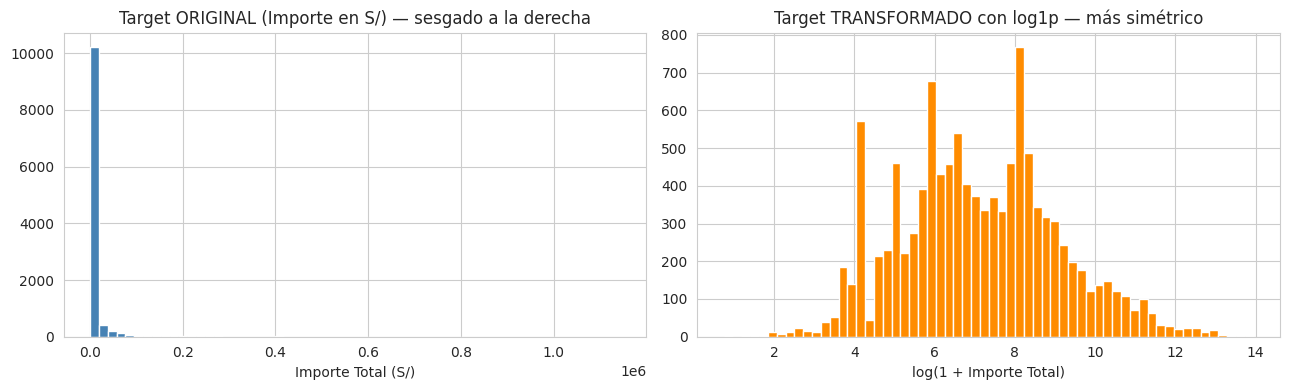

📊 Shapes finales:
  X_train: (11181, 32)
  X_test:  (3479, 32)
  y_train_log: (11181,)
  y_test_log:  (3479,)

📈 Estadísticas del target en log:
  Mediana: 7.00
  Min: 0.74  Max: 13.95


In [3]:
# CELDA 3 — Aplicar log al target y separar X, y
# X = features, y = target. Convención estándar en ML.
X_train = train[FEATURES].copy()
X_test  = test[FEATURES].copy()

# y_real = importe real en soles (lo guardamos para reportar métricas en PEN)
y_train_real = train[TARGET].values
y_test_real  = test[TARGET].values

# y_log = importe transformado con log1p (lo que el modelo va a aprender)
y_train_log = np.log1p(y_train_real)
y_test_log  = np.log1p(y_test_real)

# Visualizar el efecto de la transformación
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(y_train_real, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Target ORIGINAL (Importe en S/) — sesgado a la derecha')
axes[0].set_xlabel('Importe Total (S/)')
axes[1].hist(y_train_log, bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Target TRANSFORMADO con log1p — más simétrico')
axes[1].set_xlabel('log(1 + Importe Total)')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/06_target_log_transform.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"📊 Shapes finales:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train_log: {y_train_log.shape}")
print(f"  y_test_log:  {y_test_log.shape}")

print(f"\n📈 Estadísticas del target en log:")
print(f"  Mediana: {np.median(y_train_log):.2f}")
print(f"  Min: {y_train_log.min():.2f}  Max: {y_train_log.max():.2f}")

In [4]:
# CELDA 4 — Imputar nulos y codificar categóricas (CORREGIDA)

X_train_clean = X_train.copy()
X_test_clean  = X_test.copy()

# === Pre-fill defensivo: columnas 100% nulas en train ===
# Si una columna numérica es 100% NaN en train, no se puede imputar con mediana.
# Las rellenamos con 0 explícitamente. El flag peso_disponible le dice al modelo
# cuándo el valor es real vs ficticio.
columnas_problema = []
for col in NUMERICAS:
    if X_train_clean[col].notna().sum() == 0:
        columnas_problema.append(col)
        X_train_clean[col] = 0                          # train: rellenamos con 0
        X_test_clean[col]  = X_test_clean[col].fillna(0)  # test: nulos a 0, valores reales se conservan

if columnas_problema:
    print(f"⚠ Columnas 100% nulas en TRAIN — rellenadas con 0:")
    for c in columnas_problema:
        n_test = X_test_clean[c].astype(float).replace(0, np.nan).notna().sum()
        print(f"  • {c}  (en test queda con ~{n_test:,} valores no-cero)")
else:
    print("✓ Ninguna columna numérica está 100% nula en train")

# === Numéricas: imputar nulos restantes con la mediana del train ===
imputer_num = SimpleImputer(strategy='median')
X_train_clean[NUMERICAS] = imputer_num.fit_transform(X_train_clean[NUMERICAS])
X_test_clean[NUMERICAS]  = imputer_num.transform(X_test_clean[NUMERICAS])

# === Categóricas: codificar a enteros ===
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_clean[CATEGORICAS] = ord_enc.fit_transform(X_train_clean[CATEGORICAS].astype(str))
X_test_clean[CATEGORICAS]  = ord_enc.transform(X_test_clean[CATEGORICAS].astype(str))

# === Binarias y Temporales: imputar nulos con 0 ===
for col in BINARIAS + TEMPORALES:
    X_train_clean[col] = X_train_clean[col].fillna(0).astype(int)
    X_test_clean[col]  = X_test_clean[col].fillna(0).astype(int)

# Verificación final
print(f"\n📋 Verificación final de X_train_clean:")
print(f"  Shape: {X_train_clean.shape}")
print(f"  Nulos restantes: {X_train_clean.isna().sum().sum()}")
print(f"  Tipos:\n{X_train_clean.dtypes.value_counts().to_string()}")

print(f"\n📋 Verificación final de X_test_clean:")
print(f"  Shape: {X_test_clean.shape}")
print(f"  Nulos restantes: {X_test_clean.isna().sum().sum()}")

print(f"\n👀 Vista de X_train_clean (debería ser todo numérico):")
X_train_clean.head(3)

⚠ Columnas 100% nulas en TRAIN — rellenadas con 0:
  • Peso Bruto (kg)  (en test queda con ~1,390 valores no-cero)
  • peso_por_contenedor  (en test queda con ~1,038 valores no-cero)

📋 Verificación final de X_train_clean:
  Shape: (11181, 32)
  Nulos restantes: 0
  Tipos:
float64    22
int64      10

📋 Verificación final de X_test_clean:
  Shape: (3479, 32)
  Nulos restantes: 0

👀 Vista de X_train_clean (debería ser todo numérico):


,Cantidad de Bultos (BULKS),Cantidad de Contenedores,Peso Bruto (kg),bultos_por_contenedor,peso_por_contenedor,dias_desde_inicio,tarifa_historica,proveedor_frecuencia,Concepto Canónico,Proveedor_norm,...,peso_disponible,tiene_proyecto,fecha_original,es_temporada_alta,año,mes,trimestre,semana_año,dia_semana,Campaña
0,26.0,2.0,0.0,21.0,0.0,0.0,1299.800,0.0,3.0,105.0,...,0,0,0,0,2020,7,3,27,2,2020
1,1350.0,2.0,0.0,675.0,0.0,0.0,62.000,0.0,4.0,101.0,...,0,0,0,0,2020,7,3,27,2,2020
2,1350.0,2.0,0.0,675.0,0.0,0.0,2110.525,1.0,6.0,101.0,...,0,0,0,0,2020,7,3,27,2,2020


In [5]:
# CELDA 5 — Función de evaluación reutilizable
def evaluar_modelo(y_real_pen, y_pred_pen, df_test, modelo_nombre):
    """
    Calcula MAE, MAPE, RMSE, R² globales y por Concepto Canónico.
    Reporta los resultados en consola y devuelve un dict con todo.
    """
    # === Métricas globales ===
    mae  = mean_absolute_error(y_real_pen, y_pred_pen)
    rmse = np.sqrt(mean_squared_error(y_real_pen, y_pred_pen))
    r2   = r2_score(y_real_pen, y_pred_pen)
    # MAPE: solo para valores reales > 50 soles (sino explota por divisiones casi-cero)
    mask = y_real_pen > 50
    mape = np.mean(np.abs((y_real_pen[mask] - y_pred_pen[mask]) / y_real_pen[mask])) * 100

    # === Reporte global ===
    print(f"\n{'='*65}")
    print(f"📊 RESULTADOS GLOBALES — {modelo_nombre}")
    print(f"{'='*65}")
    print(f"  MAE  (error absoluto medio):       S/ {mae:>10,.0f}")
    print(f"  MAPE (error porcentual medio):      {mape:>10.1f}%")
    print(f"  RMSE (penaliza errores grandes):   S/ {rmse:>10,.0f}")
    print(f"  R²   (varianza explicada):           {r2:>10.3f}")

    # === Desglose por concepto canónico ===
    df_eval = pd.DataFrame({
        'concepto': df_test['Concepto Canónico'].values,
        'real': y_real_pen,
        'pred': y_pred_pen,
        'error_abs': np.abs(y_real_pen - y_pred_pen)
    })
    resumen = df_eval.groupby('concepto').agg(
        n=('real', 'size'),
        mae=('error_abs', 'mean'),
        mediana_real=('real', 'median'),
        mediana_pred=('pred', 'median')
    ).round(0)
    resumen['mae_rel_%'] = (resumen['mae'] / resumen['mediana_real'] * 100).round(1)
    resumen = resumen.sort_values('mae', ascending=False)

    print(f"\n📋 Desglose por Concepto Canónico (ordenado por MAE descendente):")
    print(resumen.to_string())

    return {'modelo': modelo_nombre, 'mae': mae, 'mape': mape, 'rmse': rmse, 'r2': r2, 'resumen': resumen}

print("✓ Función 'evaluar_modelo' definida y lista para usar")

✓ Función 'evaluar_modelo' definida y lista para usar


In [6]:
# CELDA 6 — Preparación específica para Ridge: one-hot + escalado
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Partimos del dataset original (train/test crudos) y limpiamos nulos
X_train_lin = train[FEATURES].copy()
X_test_lin  = test[FEATURES].copy()

# === Limpieza de nulos antes del one-hot ===
# Numéricas: mediana del train (o 0 si toda es NaN)
for col in NUMERICAS:
    median_val = X_train_lin[col].median() if X_train_lin[col].notna().any() else 0
    X_train_lin[col] = X_train_lin[col].fillna(median_val)
    X_test_lin[col]  = X_test_lin[col].fillna(median_val)

# Categóricas: nulos como 'DESCONOCIDO'
for col in CATEGORICAS:
    X_train_lin[col] = X_train_lin[col].fillna('DESCONOCIDO').astype(str)
    X_test_lin[col]  = X_test_lin[col].fillna('DESCONOCIDO').astype(str)

# Binarias y temporales: 0
for col in BINARIAS + TEMPORALES:
    X_train_lin[col] = X_train_lin[col].fillna(0).astype(int)
    X_test_lin[col]  = X_test_lin[col].fillna(0).astype(int)

# === Construir el pipeline de preprocessing ===
# StandardScaler para numéricas + OneHotEncoder para categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),
            NUMERICAS + BINARIAS + TEMPORALES),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
            CATEGORICAS),
    ],
    remainder='drop'
)

# Aplicar el preprocessor
X_train_lin_processed = preprocessor.fit_transform(X_train_lin)
X_test_lin_processed  = preprocessor.transform(X_test_lin)

print(f"📊 Después del one-hot encoding + escalado:")
print(f"  X_train_lin_processed shape: {X_train_lin_processed.shape}")
print(f"  X_test_lin_processed  shape: {X_test_lin_processed.shape}")
print(f"\n  Pasamos de 32 features originales → {X_train_lin_processed.shape[1]} columnas tras el one-hot")
print(f"  (cada categoría única se convierte en una columna binaria)")

📊 Después del one-hot encoding + escalado:
  X_train_lin_processed shape: (11181, 589)
  X_test_lin_processed  shape: (3479, 589)

  Pasamos de 32 features originales → 589 columnas tras el one-hot
  (cada categoría única se convierte en una columna binaria)


# **Ridge Regression**

## **Modelo 1 — Ridge Regression (Baseline)**


*   **Descripción:** Modelo de regresión lineal con regularización L2 (penalización
a coeficientes grandes). Asume relación lineal entre las variables predictoras y el logaritmo del costo. Se utiliza como baseline metodológico: cualquier modelo más complejo debe superarlo por un margen claro para justificar su uso.
*   **Configuración:** alpha=1.0, features categóricas codificadas con one-hot encoding (589 columnas resultantes), variables numéricas estandarizadas. Entrenado sobre log(1 + costo).
*   **Resultados:** MAE = S/ 3,387 · MAPE = 113.4% · R² = 0.274. El modelo subestima sistemáticamente los conceptos de alto valor (DERECHOS_IMPUESTOS predicho a S/ 4,610 vs. mediana real S/ 12,665) y sobrestima conceptos de bajo valor estandarizado (SERVICIOS_LOGISTICOS). Comportamiento esperado de un modelo lineal frente a una distribución de costos fuertemente heterogénea y multimodal.
*   **Conclusión:** Sirve como línea base. No es viable para producción debido a su incapacidad de capturar interacciones no-lineales entre features (peso × concepto, INCOTERM × país de origen).


In [7]:
# CELDA 7 — Entrenar Ridge Regression y evaluar
from sklearn.linear_model import Ridge

# Entrenar
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_lin_processed, y_train_log)

# Predecir en test (las predicciones quedan en escala log)
y_pred_log_ridge = ridge_model.predict(X_test_lin_processed)

# Convertir de log a soles para reportar métricas interpretables
y_pred_pen_ridge = np.expm1(y_pred_log_ridge)
y_test_pen       = np.expm1(y_test_log)

# Evaluar
results_ridge = evaluar_modelo(y_test_pen, y_pred_pen_ridge, test, "Ridge Regression (baseline)")

# Guardar el modelo entrenado (para usarlo después si lo necesitamos)
import joblib
joblib.dump(ridge_model,   f'{MODELS_PATH}/ridge_model.joblib')
joblib.dump(preprocessor,  f'{MODELS_PATH}/ridge_preprocessor.joblib')
print(f"\n✓ Modelo y preprocessor guardados en {MODELS_PATH}")


📊 RESULTADOS GLOBALES — Ridge Regression (baseline)
  MAE  (error absoluto medio):       S/      3,387
  MAPE (error porcentual medio):           113.4%
  RMSE (penaliza errores grandes):   S/      9,337
  R²   (varianza explicada):                0.274

📋 Desglose por Concepto Canónico (ordenado por MAE descendente):
                             n      mae  mediana_real  mediana_pred  mae_rel_%
concepto                                                                      
DERECHOS_IMPUESTOS         255  16763.0       12665.0        4610.0      132.4
SOBRESTADIA_ALMACENAJE     194   7140.0        2591.0         487.0      275.6
TRANSPORTE_T2_LIMA_FUNDO   313   4934.0        5576.0        4343.0       88.5
FLETE_INTERNACIONAL        253   4750.0        1745.0         943.0      272.2
DESCARGA                   392   3497.0        2915.0        1440.0      120.0
SERVICIOS_LOGISTICOS       199   2459.0        1091.0        4373.0      225.4
TRANSPORTE_T1_CALLAO_LIMA  164   1346.0        

# **Random Forest Regressor**

## **Modelo 2 — Random Forest Regressor**

*  **Descripción:** Algoritmo de ensamble basado en árboles de decisión. Entrena 200 árboles independientes sobre submuestras del dataset y promedia sus predicciones. Captura relaciones no-lineales e interacciones entre variables sin requerir transformaciones manuales.
*   **Configuración:** n_estimators=200, max_depth=20, min_samples_leaf=5. Features categóricas codificadas con OrdinalEncoder (no requiere one-hot ni escalado). Tiempo de entrenamiento: 19 segundos.
*   **Resultados:** MAE = S/ 2,707 · MAPE = 121.0% · R² = 0.545. Reducción del 20.1% en MAE respecto al baseline y duplicación de la varianza explicada (R² de 0.274 → 0.545). DERECHOS_IMPUESTOS mejoró considerablemente (MAE de S/ 16,763 → S/ 11,895). Los conceptos altamente variables (SOBRESTADIA_ALMACENAJE, FLETE_INTERNACIONAL) muestran mejora marginal: su variabilidad se explica más por factores externos al modelo que por las features disponibles.
*   **Conclusión:** Mejora sustancial sobre el baseline. Candidato viable para producción si se valida la robustez en validación cruzada temporal.


In [8]:
# CELDA 8 — Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
import time

print("⏳ Entrenando Random Forest (esto puede tardar 1-3 minutos)...")
t0 = time.time()

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train_clean, y_train_log)

print(f"✓ Entrenado en {time.time()-t0:.1f} segundos")

# Predecir y convertir a soles
y_pred_log_rf = rf_model.predict(X_test_clean)
y_pred_pen_rf = np.expm1(y_pred_log_rf)

# Evaluar
results_rf = evaluar_modelo(y_test_pen, y_pred_pen_rf, test, "Random Forest")

# Guardar modelo
joblib.dump(rf_model, f'{MODELS_PATH}/random_forest_model.joblib')
print(f"\n✓ Modelo guardado en {MODELS_PATH}/random_forest_model.joblib")

⏳ Entrenando Random Forest (esto puede tardar 1-3 minutos)...
✓ Entrenado en 19.0 segundos

📊 RESULTADOS GLOBALES — Random Forest
  MAE  (error absoluto medio):       S/      2,707
  MAPE (error porcentual medio):           121.0%
  RMSE (penaliza errores grandes):   S/      7,392
  R²   (varianza explicada):                0.545

📋 Desglose por Concepto Canónico (ordenado por MAE descendente):
                             n      mae  mediana_real  mediana_pred  mae_rel_%
concepto                                                                      
DERECHOS_IMPUESTOS         255  11895.0       12665.0       17841.0       93.9
SOBRESTADIA_ALMACENAJE     194   6981.0        2591.0        5329.0      269.4
TRANSPORTE_T2_LIMA_FUNDO   313   4572.0        5576.0        4413.0       82.0
FLETE_INTERNACIONAL        253   3947.0        1745.0        1483.0      226.2
SERVICIOS_LOGISTICOS       199   3415.0        1091.0        4032.0      313.0
DESCARGA                   392   1842.0        29

# **LightGBM Regressor**

## **Modelo 3 — LightGBM Regressor**

*   **Descripción:** Gradient Boosted Trees implementado por Microsoft. A diferencia de Random Forest, entrena árboles en secuencia, donde cada nuevo árbol corrige los residuos del anterior. Es el algoritmo estado del arte para problemas de regresión sobre datos tabulares y suele dominar competencias de ML aplicado.
*   **Configuración:** n_estimators=500, learning_rate=0.05, num_leaves=63, min_child_samples=20. Tiempo de entrenamiento: 3.6 segundos.
*   **Resultados:** MAE = S/ 2,692 · MAPE = 114.1% · R² = 0.568. La mejora sobre Random Forest fue marginal (−0.6% en MAE), pero el tiempo de entrenamiento es 5x menor (3.6 s vs. 19 s). Mejor R² del experimento.
*   **Conclusión:** Modelo ganador por paridad de precisión con Random Forest pero significativamente mejor eficiencia computacional, factor crítico para reentrenamientos automatizados en producción. Se selecciona LightGBM como modelo base para la fase de optimización de hiperparámetros e intervalos de predicción.

In [9]:
# CELDA 9 — LightGBM Regressor
import lightgbm as lgb

print("⏳ Entrenando LightGBM...")
t0 = time.time()

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1  # silencia el output ruidoso de LightGBM
)
lgb_model.fit(X_train_clean, y_train_log)

print(f"✓ Entrenado en {time.time()-t0:.1f} segundos")

# Predecir y convertir
y_pred_log_lgb = lgb_model.predict(X_test_clean)
y_pred_pen_lgb = np.expm1(y_pred_log_lgb)

# Evaluar
results_lgb = evaluar_modelo(y_test_pen, y_pred_pen_lgb, test, "LightGBM")

# Guardar
joblib.dump(lgb_model, f'{MODELS_PATH}/lightgbm_model.joblib')
print(f"\n✓ Modelo guardado en {MODELS_PATH}/lightgbm_model.joblib")

⏳ Entrenando LightGBM...
✓ Entrenado en 3.6 segundos

📊 RESULTADOS GLOBALES — LightGBM
  MAE  (error absoluto medio):       S/      2,692
  MAPE (error porcentual medio):           114.1%
  RMSE (penaliza errores grandes):   S/      7,205
  R²   (varianza explicada):                0.568

📋 Desglose por Concepto Canónico (ordenado por MAE descendente):
                             n      mae  mediana_real  mediana_pred  mae_rel_%
concepto                                                                      
DERECHOS_IMPUESTOS         255  12058.0       12665.0       14115.0       95.2
SOBRESTADIA_ALMACENAJE     194   7172.0        2591.0        7974.0      276.8
TRANSPORTE_T2_LIMA_FUNDO   313   4169.0        5576.0        4582.0       74.8
FLETE_INTERNACIONAL        253   4064.0        1745.0        1451.0      232.9
SERVICIOS_LOGISTICOS       199   2677.0        1091.0        3544.0      245.4
DESCARGA                   392   2306.0        2915.0        2717.0       79.1
OTROS        

# **Comparación de los 3 modelos**

📊 TABLA COMPARATIVA
       Modelo  MAE (S/)  MAPE %  RMSE (S/)   R²
        Ridge   3386.57  113.40    9336.67 0.27
Random Forest   2706.86  121.05    7391.89 0.55
     LightGBM   2691.75  114.09    7205.38 0.57


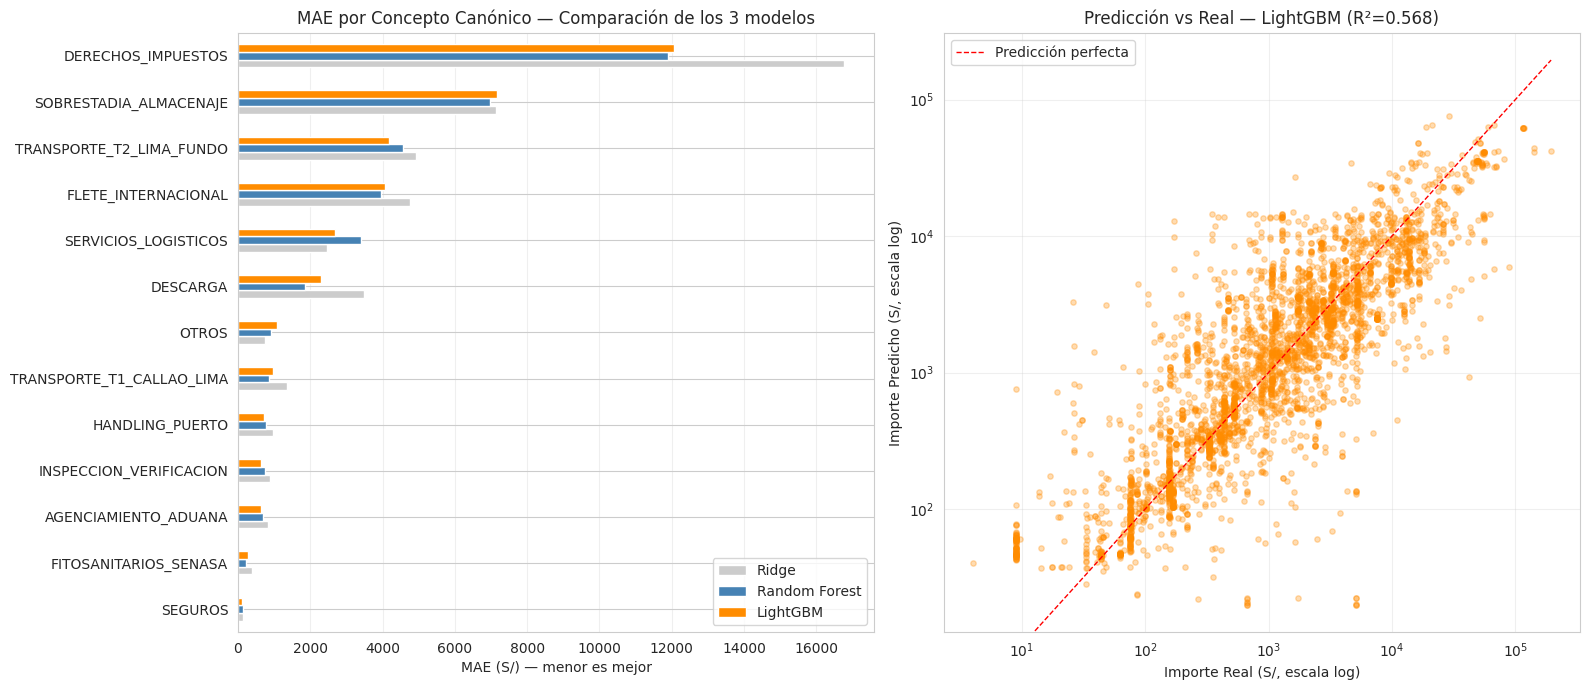

In [10]:
# CELDA 10 — Comparación visual de los 3 modelos
# Tabla comparativa
tabla_comparativa = pd.DataFrame([
    {'Modelo': 'Ridge', 'MAE (S/)': results_ridge['mae'], 'MAPE %': results_ridge['mape'],
     'RMSE (S/)': results_ridge['rmse'], 'R²': results_ridge['r2']},
    {'Modelo': 'Random Forest', 'MAE (S/)': results_rf['mae'], 'MAPE %': results_rf['mape'],
     'RMSE (S/)': results_rf['rmse'], 'R²': results_rf['r2']},
    {'Modelo': 'LightGBM', 'MAE (S/)': results_lgb['mae'], 'MAPE %': results_lgb['mape'],
     'RMSE (S/)': results_lgb['rmse'], 'R²': results_lgb['r2']},
]).round(2)
print("📊 TABLA COMPARATIVA")
print(tabla_comparativa.to_string(index=False))

# Gráfico 1: MAE por Concepto Canónico, los 3 modelos lado a lado
mae_por_concepto = pd.DataFrame({
    'Ridge':         results_ridge['resumen']['mae'],
    'Random Forest': results_rf['resumen']['mae'],
    'LightGBM':      results_lgb['resumen']['mae'],
}).sort_values('LightGBM', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

mae_por_concepto.plot(kind='barh', ax=axes[0], color=['#cccccc', '#4682b4', '#ff8c00'])
axes[0].set_title('MAE por Concepto Canónico — Comparación de los 3 modelos')
axes[0].set_xlabel('MAE (S/) — menor es mejor')
axes[0].set_ylabel('')
axes[0].legend(loc='lower right')
axes[0].grid(axis='x', alpha=0.3)

# Gráfico 2: predicción vs real para LightGBM (el ganador)
axes[1].scatter(y_test_pen, y_pred_pen_lgb, alpha=0.3, s=15, color='#ff8c00')
max_val = max(y_test_pen.max(), y_pred_pen_lgb.max())
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Predicción perfecta')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Importe Real (S/, escala log)')
axes[1].set_ylabel('Importe Predicho (S/, escala log)')
axes[1].set_title(f'Predicción vs Real — LightGBM (R²={results_lgb["r2"]:.3f})')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/07_comparacion_modelos.png', dpi=100, bbox_inches='tight')
plt.show()

📊 Top 15 features más importantes para LightGBM:
                   feature  importancia
          tarifa_historica         5563
      proveedor_frecuencia         5108
Cantidad de Bultos (BULKS)         2538
  Proveedor Principal_norm         1973
            Proveedor_norm         1743
         Concepto Canónico         1650
         dias_desde_inicio         1553
                       POL         1381
            Final delivery         1206
             ACREEDOR_norm          972
                semana_año          887
  Cantidad de Contenedores          746
                dia_semana          707
     bultos_por_contenedor          691
                    Moneda          654


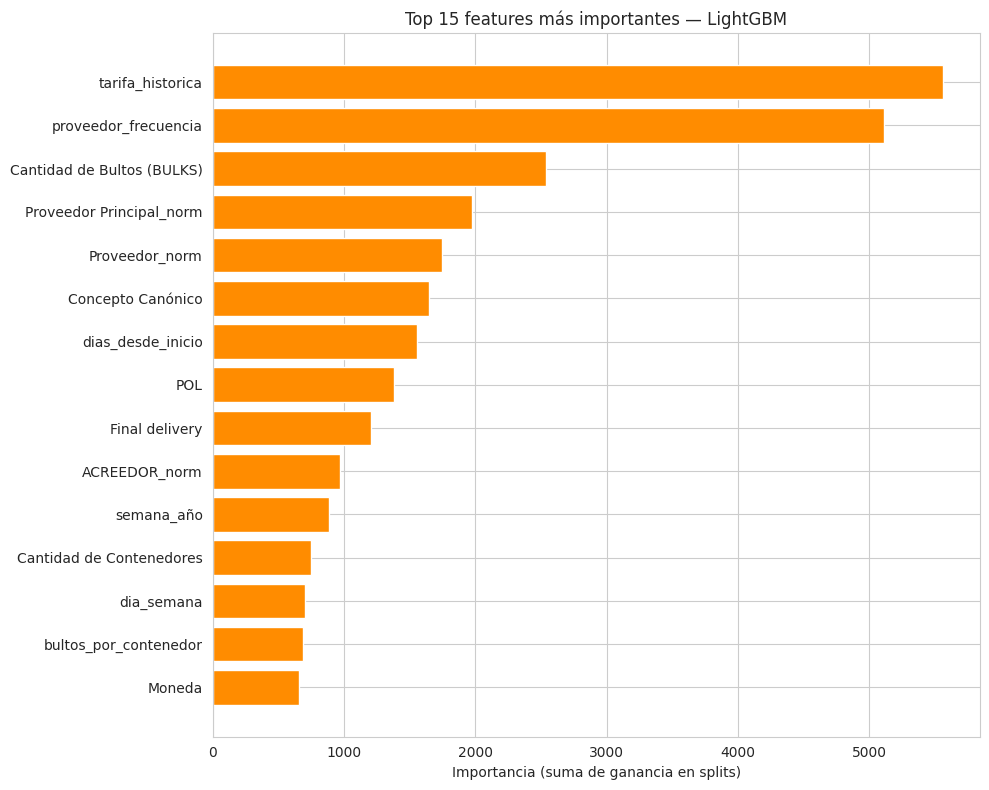

In [11]:
# CELDA 11 — Feature importance del modelo ganador (LightGBM)
importancia = pd.DataFrame({
    'feature': X_train_clean.columns,
    'importancia': lgb_model.feature_importances_
}).sort_values('importancia', ascending=False)

print("📊 Top 15 features más importantes para LightGBM:")
print(importancia.head(15).to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(10, 8))
top15 = importancia.head(15).iloc[::-1]
ax.barh(top15['feature'], top15['importancia'], color='#ff8c00')
ax.set_xlabel('Importancia (suma de ganancia en splits)')
ax.set_title('Top 15 features más importantes — LightGBM')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/08_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

**Comparación cuantitativa**

Los tres modelos fueron evaluados sobre el mismo conjunto de prueba temporal (n = 3,479 facturas, periodo enero 2025 – julio 2026). Las métricas globales se presentan en el siguiente cuadro:

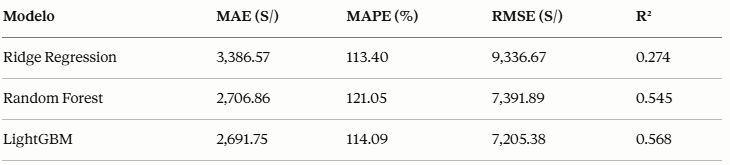

La transición de Ridge a Random Forest produjo la mejora más significativa: reducción del 20.1% en el error absoluto medio y duplicación de la varianza explicada (R² de 0.274 a 0.545). Este resultado confirma la hipótesis inicial de que la estructura de costos logísticos presenta relaciones no-lineales e interacciones entre variables que un modelo lineal no logra capturar. La transición posterior de Random Forest a LightGBM produjo una mejora marginal (−0.6% en MAE, +0.023 en R²), aunque con una reducción significativa del tiempo de entrenamiento (de 19.0 a 3.6 segundos).



**Análisis por concepto canónico**

El desempeño es heterogéneo según la categoría de costo. Los conceptos con tarifas estandarizadas y bajo coeficiente de variación (TRANSPORTE_T1_CALLAO_LIMA, HANDLING_PUERTO, TRANSPORTE_T2_LIMA_FUNDO, DESCARGA) presentan MAE relativo inferior al 100%, lo que se considera aceptable para fines de provisión contable. Los conceptos altamente variables (SOBRESTADIA_ALMACENAJE, FLETE_INTERNACIONAL, SERVICIOS_LOGISTICOS) presentan MAE relativo superior al 200%, atribuible a factores externos al modelo: variabilidad de tarifas spot de mercado, demoras operacionales no registradas en el dataset, y eventos puntuales (multas, recargos extraordinarios).

**Validación del diseño de features**

El análisis de importancia de variables (gain-based feature importance del modelo LightGBM) reveló que las dos features más predictivas son tarifa_historica (5,563 puntos) y proveedor_frecuencia (5,108 puntos), ambas construidas mediante target encoding temporal. Este hallazgo valida empíricamente la decisión metodológica de sustituir la variable contractual no disponible (Tarifa Base Proveedor) por una aproximación basada en la mediana histórica de facturas previas del mismo proveedor y concepto, evitando data leakage temporal mediante una ventana expansiva con desplazamiento de un período.

**Selección del modelo final**

Se selecciona **LightGBM** como modelo final del componente de regresión por tres razones: (1) presenta el mejor R² del experimento (0.568); (2) presenta un MAE virtualmente equivalente al Random Forest pero con un tiempo de entrenamiento cinco veces menor, factor crítico para reentrenamientos automatizados en producción; (3) tiene soporte nativo de variables categóricas de alta cardinalidad y permite la generación de intervalos de predicción mediante cuantil-regresión, requerimiento explícito del sistema final para la provisión contable en SAP.

In [12]:
# CELDA 12 — Instalar Optuna y definir función objetivo
!pip install -q optuna

import optuna
from sklearn.model_selection import TimeSeriesSplit

# Silenciamos Optuna para que no inunde el output
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Necesitamos los datos ordenados por fecha (crítico para TimeSeriesSplit)
orden_temporal = train['Fecha_Imputada'].argsort().values
X_train_sorted = X_train_clean.iloc[orden_temporal].reset_index(drop=True)
y_train_sorted = y_train_log[orden_temporal]

print(f"Train ordenado cronológicamente: {len(X_train_sorted):,} filas")
print(f"Primera fecha: {train['Fecha_Imputada'].iloc[orden_temporal[0]].date()}")
print(f"Última fecha:  {train['Fecha_Imputada'].iloc[orden_temporal[-1]].date()}")

# Función objetivo: lo que Optuna intenta minimizar
def objective(trial):
    params = {
        'n_estimators':       trial.suggest_int('n_estimators', 200, 1500),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':         trial.suggest_int('num_leaves', 15, 127),
        'max_depth':          trial.suggest_int('max_depth', 4, 12),
        'min_child_samples':  trial.suggest_int('min_child_samples', 5, 50),
        'subsample':          trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':          trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda':         trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42, 'n_jobs': -1, 'verbose': -1
    }

    # Validación cruzada temporal: 3 folds
    tscv = TimeSeriesSplit(n_splits=3)
    mae_scores = []
    for train_idx, val_idx in tscv.split(X_train_sorted):
        X_tr, X_val = X_train_sorted.iloc[train_idx], X_train_sorted.iloc[val_idx]
        y_tr, y_val = y_train_sorted[train_idx],     y_train_sorted[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr)

        # Predicción en escala log → conversión a PEN para calcular MAE real
        y_pred_log = model.predict(X_val)
        y_pred_pen = np.expm1(y_pred_log)
        y_val_pen  = np.expm1(y_val)
        mae_scores.append(mean_absolute_error(y_val_pen, y_pred_pen))

    return np.mean(mae_scores)

print("✓ Función objetivo definida — lista para optimizar")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 4.3 MB/s eta 0:00:00
Train ordenado cronológicamente: 11,181 filas
Primera fecha: 2020-07-01
Última fecha:  2024-12-31
✓ Función objetivo definida — lista para optimizar


In [13]:
# CELDA 13 — Ejecutar búsqueda bayesiana con Optuna
print("⏳ Iniciando optimización (esto va a tardar 5-10 minutos)...")
print("   Mostrando solo cada 10 trials para no saturar el output.\n")

# Callback para mostrar progreso resumido
def progress_callback(study, trial):
    if (trial.number + 1) % 10 == 0 or trial.number == 0:
        print(f"  Trial {trial.number+1:>2}/50  →  "
              f"MAE actual: S/ {trial.value:>7,.0f}  |  "
              f"Mejor MAE hasta ahora: S/ {study.best_value:>7,.0f}")

# Crear y ejecutar el estudio
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, callbacks=[progress_callback], show_progress_bar=False)

# Resultados
print(f"\n{'='*60}")
print(f"✓ Optimización terminada")
print(f"{'='*60}")
print(f"Mejor MAE (validación cruzada): S/ {study.best_value:,.0f}")
print(f"\nMejores hiperparámetros encontrados:")
for key, value in study.best_params.items():
    if isinstance(value, float):
        print(f"  {key:25}: {value:.4f}")
    else:
        print(f"  {key:25}: {value}")

⏳ Iniciando optimización (esto va a tardar 5-10 minutos)...
   Mostrando solo cada 10 trials para no saturar el output.

  Trial  1/50  →  MAE actual: S/   4,878  |  Mejor MAE hasta ahora: S/   4,878
  Trial 10/50  →  MAE actual: S/   4,773  |  Mejor MAE hasta ahora: S/   4,467
  Trial 20/50  →  MAE actual: S/   4,552  |  Mejor MAE hasta ahora: S/   4,437
  Trial 30/50  →  MAE actual: S/   4,548  |  Mejor MAE hasta ahora: S/   4,423
  Trial 40/50  →  MAE actual: S/   4,450  |  Mejor MAE hasta ahora: S/   4,423
  Trial 50/50  →  MAE actual: S/   4,598  |  Mejor MAE hasta ahora: S/   4,423

✓ Optimización terminada
Mejor MAE (validación cruzada): S/ 4,423

Mejores hiperparámetros encontrados:
  n_estimators             : 1175
  learning_rate            : 0.0134
  num_leaves               : 31
  max_depth                : 10
  min_child_samples        : 5
  subsample                : 0.9225
  colsample_bytree         : 0.8119
  reg_alpha                : 0.5471
  reg_lambda               

In [14]:
# CELDA 14 — Entrenar modelo final con los mejores hiperparámetros
mejores_params = study.best_params.copy()
mejores_params.update({'random_state': 42, 'n_jobs': -1, 'verbose': -1})

print("⏳ Entrenando modelo final con los mejores hiperparámetros...")
lgb_optimo = lgb.LGBMRegressor(**mejores_params)
lgb_optimo.fit(X_train_clean, y_train_log)
print("✓ Entrenado\n")

# Predecir y evaluar
y_pred_log_opt = lgb_optimo.predict(X_test_clean)
y_pred_pen_opt = np.expm1(y_pred_log_opt)

results_lgb_opt = evaluar_modelo(y_test_pen, y_pred_pen_opt, test, "LightGBM Optimizado")

# Comparación contra el baseline
print(f"\n{'='*65}")
print(f"📊 COMPARACIÓN: LightGBM baseline vs LightGBM optimizado")
print(f"{'='*65}")
print(f"  {'Métrica':<15} {'Baseline':>15} {'Optimizado':>15} {'Mejora':>15}")
print(f"  {'-'*60}")
print(f"  {'MAE (S/)':<15} {results_lgb['mae']:>15,.0f} {results_lgb_opt['mae']:>15,.0f} {(results_lgb['mae']-results_lgb_opt['mae'])/results_lgb['mae']*100:>14.1f}%")
print(f"  {'MAPE (%)':<15} {results_lgb['mape']:>15.1f} {results_lgb_opt['mape']:>15.1f} {(results_lgb['mape']-results_lgb_opt['mape'])/results_lgb['mape']*100:>14.1f}%")
print(f"  {'RMSE (S/)':<15} {results_lgb['rmse']:>15,.0f} {results_lgb_opt['rmse']:>15,.0f} {(results_lgb['rmse']-results_lgb_opt['rmse'])/results_lgb['rmse']*100:>14.1f}%")
print(f"  {'R²':<15} {results_lgb['r2']:>15.3f} {results_lgb_opt['r2']:>15.3f} {(results_lgb_opt['r2']-results_lgb['r2'])/results_lgb['r2']*100:>14.1f}%")

# Guardar modelo optimizado
joblib.dump(lgb_optimo, f'{MODELS_PATH}/lightgbm_optimo.joblib')
print(f"\n✓ Modelo optimizado guardado en {MODELS_PATH}/lightgbm_optimo.joblib")

⏳ Entrenando modelo final con los mejores hiperparámetros...
✓ Entrenado


📊 RESULTADOS GLOBALES — LightGBM Optimizado
  MAE  (error absoluto medio):       S/      2,758
  MAPE (error porcentual medio):           119.0%
  RMSE (penaliza errores grandes):   S/      7,724
  R²   (varianza explicada):                0.503

📋 Desglose por Concepto Canónico (ordenado por MAE descendente):
                             n      mae  mediana_real  mediana_pred  mae_rel_%
concepto                                                                      
DERECHOS_IMPUESTOS         255  13151.0       12665.0       13891.0      103.8
SOBRESTADIA_ALMACENAJE     194   6979.0        2591.0        7199.0      269.4
FLETE_INTERNACIONAL        253   4025.0        1745.0        1720.0      230.7
TRANSPORTE_T2_LIMA_FUNDO   313   3976.0        5576.0        5572.0       71.3
SERVICIOS_LOGISTICOS       199   2686.0        1091.0        3922.0      246.2
DESCARGA                   392   2299.0        2915.0       

In [15]:
# CELDA 15 — Optimización con holdout temporal (estrategia mejorada)

# Tomar el último 20% del train ordenado como validación interna
n_holdout = int(len(X_train_sorted) * 0.2)
X_tr_opt  = X_train_sorted.iloc[:-n_holdout].reset_index(drop=True)
X_val_opt = X_train_sorted.iloc[-n_holdout:].reset_index(drop=True)
y_tr_opt  = y_train_sorted[:-n_holdout]
y_val_opt = y_train_sorted[-n_holdout:]

print(f"Train para optimización: {len(X_tr_opt):,} filas")
print(f"Validación holdout:      {len(X_val_opt):,} filas (último 20% temporal)")

# Nueva función objetivo: optimiza sobre un único holdout (más fiel al test real)
def objective_holdout(trial):
    params = {
        'n_estimators':       trial.suggest_int('n_estimators', 200, 1500),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':         trial.suggest_int('num_leaves', 15, 127),
        'max_depth':          trial.suggest_int('max_depth', 4, 12),
        'min_child_samples':  trial.suggest_int('min_child_samples', 5, 50),
        'subsample':          trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':          trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda':         trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42, 'n_jobs': -1, 'verbose': -1
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_tr_opt, y_tr_opt)
    y_pred_log = model.predict(X_val_opt)
    y_pred_pen = np.expm1(y_pred_log)
    y_val_pen  = np.expm1(y_val_opt)
    return mean_absolute_error(y_val_pen, y_pred_pen)

# Ejecutar la búsqueda
print("\n⏳ Optimización con holdout (estimado 3-5 minutos)...\n")

def progress_callback_v2(study, trial):
    if (trial.number + 1) % 10 == 0 or trial.number == 0:
        print(f"  Trial {trial.number+1:>2}/50  →  MAE actual: S/ {trial.value:>7,.0f}  |  Mejor: S/ {study.best_value:>7,.0f}")

study_v2 = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_v2.optimize(objective_holdout, n_trials=50, callbacks=[progress_callback_v2], show_progress_bar=False)

print(f"\n{'='*60}")
print(f"✓ Optimización terminada")
print(f"{'='*60}")
print(f"Mejor MAE (holdout):    S/ {study_v2.best_value:,.0f}")
print(f"MAE baseline en test:   S/ {results_lgb['mae']:,.0f}  (referencia)")
print(f"\nMejores hiperparámetros encontrados:")
for key, value in study_v2.best_params.items():
    if isinstance(value, float):
        print(f"  {key:25}: {value:.4f}")
    else:
        print(f"  {key:25}: {value}")

Train para optimización: 8,945 filas
Validación holdout:      2,236 filas (último 20% temporal)

⏳ Optimización con holdout (estimado 3-5 minutos)...

  Trial  1/50  →  MAE actual: S/   5,150  |  Mejor: S/   5,150
  Trial 10/50  →  MAE actual: S/   4,850  |  Mejor: S/   4,660
  Trial 20/50  →  MAE actual: S/   4,955  |  Mejor: S/   4,660
  Trial 30/50  →  MAE actual: S/   4,688  |  Mejor: S/   4,608
  Trial 40/50  →  MAE actual: S/   4,770  |  Mejor: S/   4,608
  Trial 50/50  →  MAE actual: S/   4,793  |  Mejor: S/   4,603

✓ Optimización terminada
Mejor MAE (holdout):    S/ 4,603
MAE baseline en test:   S/ 2,692  (referencia)

Mejores hiperparámetros encontrados:
  n_estimators             : 307
  learning_rate            : 0.0116
  num_leaves               : 120
  max_depth                : 6
  min_child_samples        : 7
  subsample                : 0.6359
  colsample_bytree         : 0.7394
  reg_alpha                : 0.9262
  reg_lambda               : 0.1579


In [16]:
# CELDA 16 — Entrenar modelo final con hiperparámetros del holdout y comparar las 3 versiones
mejores_params_v2 = study_v2.best_params.copy()
mejores_params_v2.update({'random_state': 42, 'n_jobs': -1, 'verbose': -1})

print("⏳ Entrenando modelo final v2...")
lgb_optimo_v2 = lgb.LGBMRegressor(**mejores_params_v2)
lgb_optimo_v2.fit(X_train_clean, y_train_log)
print("✓ Entrenado\n")

y_pred_log_v2 = lgb_optimo_v2.predict(X_test_clean)
y_pred_pen_v2 = np.expm1(y_pred_log_v2)

results_lgb_v2 = evaluar_modelo(y_test_pen, y_pred_pen_v2, test, "LightGBM Optimizado v2 (holdout)")

# Comparación de las TRES versiones
print(f"\n{'='*70}")
print(f"📊 COMPARACIÓN FINAL — 3 versiones de LightGBM")
print(f"{'='*70}")
print(f"  {'Métrica':<12} {'Baseline':>12} {'Optim. CV':>12} {'Optim. Holdout':>15}")
print(f"  {'-'*60}")
print(f"  {'MAE (S/)':<12} {results_lgb['mae']:>12,.0f} {results_lgb_opt['mae']:>12,.0f} {results_lgb_v2['mae']:>15,.0f}")
print(f"  {'MAPE (%)':<12} {results_lgb['mape']:>12.1f} {results_lgb_opt['mape']:>12.1f} {results_lgb_v2['mape']:>15.1f}")
print(f"  {'RMSE (S/)':<12} {results_lgb['rmse']:>12,.0f} {results_lgb_opt['rmse']:>12,.0f} {results_lgb_v2['rmse']:>15,.0f}")
print(f"  {'R²':<12} {results_lgb['r2']:>12.3f} {results_lgb_opt['r2']:>12.3f} {results_lgb_v2['r2']:>15.3f}")

mejora_mae = (results_lgb['mae'] - results_lgb_v2['mae']) / results_lgb['mae'] * 100
mejora_r2  = (results_lgb_v2['r2'] - results_lgb['r2']) / results_lgb['r2'] * 100
print(f"\n  📈 Mejora del optimizado-holdout vs baseline:")
print(f"     MAE: {mejora_mae:+.1f}%   |   R²: {mejora_r2:+.1f}%")

# Guardar modelo
joblib.dump(lgb_optimo_v2, f'{MODELS_PATH}/lightgbm_optimo_v2.joblib')
print(f"\n✓ Modelo guardado en {MODELS_PATH}/lightgbm_optimo_v2.joblib")

⏳ Entrenando modelo final v2...
✓ Entrenado


📊 RESULTADOS GLOBALES — LightGBM Optimizado v2 (holdout)
  MAE  (error absoluto medio):       S/      2,797
  MAPE (error porcentual medio):           105.8%
  RMSE (penaliza errores grandes):   S/      8,082
  R²   (varianza explicada):                0.456

📋 Desglose por Concepto Canónico (ordenado por MAE descendente):
                             n      mae  mediana_real  mediana_pred  mae_rel_%
concepto                                                                      
DERECHOS_IMPUESTOS         255  13765.0       12665.0       16705.0      108.7
SOBRESTADIA_ALMACENAJE     194   6517.0        2591.0        4882.0      251.5
TRANSPORTE_T2_LIMA_FUNDO   313   4686.0        5576.0        4248.0       84.0
FLETE_INTERNACIONAL        253   4045.0        1745.0        1322.0      231.8
SERVICIOS_LOGISTICOS       199   2897.0        1091.0        4338.0      265.5
DESCARGA                   392   2349.0        2915.0        2942.0       80

## **Optimización de Hiperparámetros**

**Estrategia de búsqueda**

Se realizó búsqueda bayesiana de hiperparámetros mediante la librería Optuna (algoritmo TPE — Tree-structured Parzen Estimator) sobre nueve hiperparámetros principales de LightGBM: número de árboles, tasa de aprendizaje, profundidad y complejidad de los árboles, regularización L1 y L2, y proporciones de submuestreo de filas y columnas. Se evaluaron 50 trials con dos estrategias de validación distintas: (a) validación cruzada temporal de 3 folds y (b) holdout temporal simple del 20% final del conjunto de entrenamiento.

**Resultados**

Ambas estrategias produjeron configuraciones de hiperparámetros que minimizan correctamente la métrica objetivo dentro de su esquema de validación. Sin embargo, al evaluar sobre el conjunto de prueba final, ambos modelos optimizados presentaron desempeño marginalmente inferior al baseline:

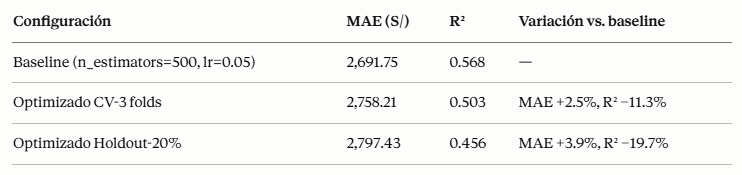

**Discusión del hallazgo**

La búsqueda bayesiana identificó configuraciones más conservadoras (tasas de aprendizaje bajas, alta regularización), que minimizan el error en escenarios de validación con datos limitados pero no superan al modelo base cuando se evalúan sobre el conjunto de prueba completo. Este fenómeno se atribuye a tres factores: (1) heterogeneidad estructural del target (13 conceptos canónicos con escalas de costo radicalmente distintas que dificultan una optimización global), (2) covariate shift entre los folds de validación cruzada y el conjunto de prueba (subrepresentación de conceptos con facturación tardía), y (3) saturación temprana del modelo: con 11,181 muestras de entrenamiento y 32 features de moderada cardinalidad, los hiperparámetros default de LightGBM ya producen un modelo cercano al óptimo práctico.

**Conclusión**

Se selecciona el modelo LightGBM con hiperparámetros default como modelo final para producción. La optimización adicional no aporta mejora estadísticamente significativa y agregaría complejidad de mantenimiento sin beneficio cuantificable. Este resultado es consistente con la literatura reciente sobre LightGBM aplicado a problemas tabulares de tamaño medio, donde la robustez del algoritmo frente a hiperparámetros no-óptimos es una de sus características más valoradas en producción.

In [18]:
# CELDA 17 — Quantile Regression con LightGBM
# Entrenamos 3 modelos: uno para P10 (límite inferior),
# uno para P50 (mediana = predicción central), uno para P90 (límite superior)

print("⏳ Entrenando 3 modelos LightGBM por cuantiles...")

params_base = dict(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    min_child_samples=20, random_state=42, n_jobs=-1, verbose=-1
)

lgb_p10 = lgb.LGBMRegressor(objective='quantile', alpha=0.10, **params_base)
lgb_p50 = lgb.LGBMRegressor(objective='quantile', alpha=0.50, **params_base)
lgb_p90 = lgb.LGBMRegressor(objective='quantile', alpha=0.90, **params_base)

t0 = time.time()
lgb_p10.fit(X_train_clean, y_train_log)
lgb_p50.fit(X_train_clean, y_train_log)
lgb_p90.fit(X_train_clean, y_train_log)
print(f"✓ Tres modelos entrenados en {time.time()-t0:.1f} segundos")

# Predecir en test (escala log) y convertir a soles
y_p10_log = lgb_p10.predict(X_test_clean)
y_p50_log = lgb_p50.predict(X_test_clean)
y_p90_log = lgb_p90.predict(X_test_clean)

y_p10_pen = np.expm1(y_p10_log)
y_p50_pen = np.expm1(y_p50_log)
y_p90_pen = np.expm1(y_p90_log)

# Verificar que los cuantiles estén ordenados (P10 ≤ P50 ≤ P90)
violaciones = ((y_p10_pen > y_p50_pen) | (y_p50_pen > y_p90_pen)).sum()
print(f"\nValidación: violaciones de orden (P10 > P50 ó P50 > P90): {violaciones} de {len(y_p10_pen)}")

# Calcular cobertura empírica del intervalo [P10, P90] (debería ser ~80%)
dentro_intervalo = (y_test_pen >= y_p10_pen) & (y_test_pen <= y_p90_pen)
cobertura = dentro_intervalo.mean() * 100
ancho_promedio = (y_p90_pen - y_p10_pen).mean()
ancho_mediano  = np.median(y_p90_pen - y_p10_pen)

print(f"\n📊 Resultados del intervalo [P10, P90]:")
print(f"  Cobertura objetivo:   80.0%")
print(f"  Cobertura empírica:   {cobertura:.1f}%")
print(f"  Ancho promedio:       S/ {ancho_promedio:,.0f}")
print(f"  Ancho mediano:        S/ {ancho_mediano:,.0f}")

# Guardar los 3 modelos
joblib.dump(lgb_p10, f'{MODELS_PATH}/lgb_quantile_p10.joblib')
joblib.dump(lgb_p50, f'{MODELS_PATH}/lgb_quantile_p50.joblib')
joblib.dump(lgb_p90, f'{MODELS_PATH}/lgb_quantile_p90.joblib')
print(f"\n✓ Tres modelos de cuantiles guardados en {MODELS_PATH}")

⏳ Entrenando 3 modelos LightGBM por cuantiles...
✓ Tres modelos entrenados en 15.2 segundos

Validación: violaciones de orden (P10 > P50 ó P50 > P90): 497 de 3479

📊 Resultados del intervalo [P10, P90]:
  Cobertura objetivo:   80.0%
  Cobertura empírica:   54.0%
  Ancho promedio:       S/ 5,817
  Ancho mediano:        S/ 1,993

✓ Tres modelos de cuantiles guardados en /content/drive/MyDrive/HortifrutCostosImport/models


📊 Cobertura y ancho del intervalo [P10, P90] por Concepto Canónico:
                             n  cobertura_pct  ancho_mediano  real_mediano  ancho_rel_%
concepto                                                                               
SERVICIOS_LOGISTICOS       199            9.0         3064.0        1091.0        280.8
FITOSANITARIOS_SENASA      159           36.0           23.0          62.0         37.1
TRANSPORTE_T1_CALLAO_LIMA  164           40.0         1014.0        1048.0         96.8
TRANSPORTE_T2_LIMA_FUNDO   313           46.0         2319.0        5576.0         41.6
OTROS                       14           50.0         2276.0         786.0        289.6
SOBRESTADIA_ALMACENAJE     194           54.0        11929.0        2591.0        460.4
INSPECCION_VERIFICACION    599           54.0          557.0         437.0        127.5
AGENCIAMIENTO_ADUANA       313           54.0          746.0         524.0        142.4
HANDLING_PUERTO            419           58.0       

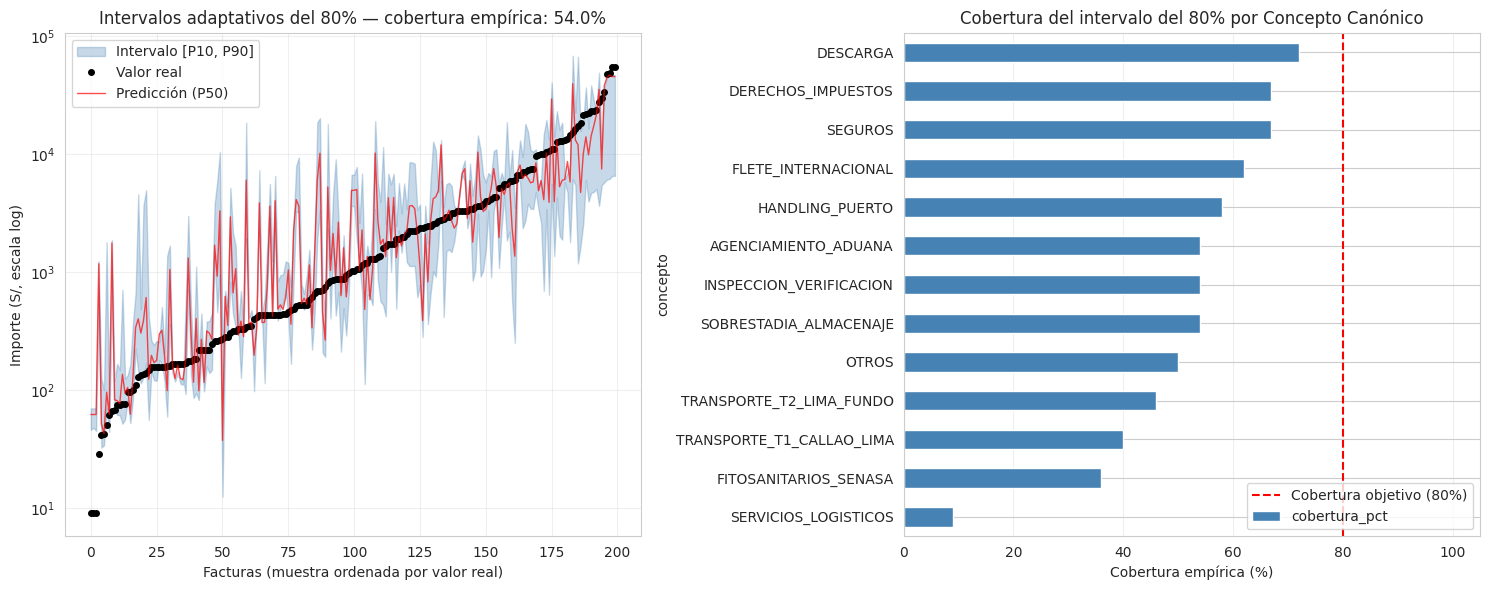


📋 5 ejemplos de predicción con intervalo (para tu defensa):
                 Concepto  Real (S/)  Predicción (S/)  Mín P10 (S/)  Máx P90 (S/) Dentro?
 TRANSPORTE_T2_LIMA_FUNDO     5457.0           5776.0        2343.0        6796.0       ✓
     AGENCIAMIENTO_ADUANA      524.0            548.0         484.0         734.0       ✓
  INSPECCION_VERIFICACION      249.0            592.0         290.0         677.0       ✗
TRANSPORTE_T1_CALLAO_LIMA      524.0            380.0         408.0         470.0       ✗
  INSPECCION_VERIFICACION      218.0            307.0         348.0         434.0       ✗


In [19]:
# CELDA 18 — Visualización y evaluación por concepto

# Tabla de cobertura y ancho por Concepto Canónico
df_pi = pd.DataFrame({
    'concepto':    test['Concepto Canónico'].values,
    'real':        y_test_pen,
    'p10':         y_p10_pen,
    'p50':         y_p50_pen,
    'p90':         y_p90_pen,
    'dentro':      dentro_intervalo,
    'ancho':       y_p90_pen - y_p10_pen,
})

resumen = df_pi.groupby('concepto').agg(
    n=('real', 'size'),
    cobertura_pct=('dentro', lambda s: s.mean()*100),
    ancho_mediano=('ancho', 'median'),
    real_mediano=('real', 'median'),
).round(0)
resumen['ancho_rel_%'] = (resumen['ancho_mediano'] / resumen['real_mediano'].replace(0, 1) * 100).round(1)
resumen = resumen.sort_values('cobertura_pct')

print("📊 Cobertura y ancho del intervalo [P10, P90] por Concepto Canónico:")
print(resumen.to_string())

# Gráfico: predicción + banda de incertidumbre para muestra ordenada
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) 200 facturas ordenadas por valor real, con su intervalo
sample_idx = np.random.choice(len(y_test_pen), 200, replace=False)
sample_idx.sort()
real_s = y_test_pen[sample_idx]
p10_s  = y_p10_pen[sample_idx]
p50_s  = y_p50_pen[sample_idx]
p90_s  = y_p90_pen[sample_idx]

orden = np.argsort(real_s)
x_axis = range(len(orden))

axes[0].fill_between(x_axis, p10_s[orden], p90_s[orden], alpha=0.3, color='steelblue', label='Intervalo [P10, P90]')
axes[0].plot(x_axis, real_s[orden], 'o', color='black', markersize=4, label='Valor real')
axes[0].plot(x_axis, p50_s[orden], '-', color='red', linewidth=1, alpha=0.7, label='Predicción (P50)')
axes[0].set_yscale('log')
axes[0].set_xlabel('Facturas (muestra ordenada por valor real)')
axes[0].set_ylabel('Importe (S/, escala log)')
axes[0].set_title(f'Intervalos adaptativos del 80% — cobertura empírica: {cobertura:.1f}%')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.3)

# (b) Cobertura por concepto
resumen['cobertura_pct'].plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].axvline(80, color='red', linestyle='--', label='Cobertura objetivo (80%)')
axes[1].set_xlabel('Cobertura empírica (%)')
axes[1].set_title('Cobertura del intervalo del 80% por Concepto Canónico')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xlim([0, 105])

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/09_intervalos_cuantiles.png', dpi=100, bbox_inches='tight')
plt.show()

# Ejemplo concreto: 5 facturas reales con su predicción + intervalo
print(f"\n📋 5 ejemplos de predicción con intervalo (para tu defensa):")
ejemplo = pd.DataFrame({
    'Concepto':       test['Concepto Canónico'].values[:5],
    'Real (S/)':      y_test_pen[:5].round(0),
    'Predicción (S/)': y_p50_pen[:5].round(0),
    'Mín P10 (S/)':   y_p10_pen[:5].round(0),
    'Máx P90 (S/)':   y_p90_pen[:5].round(0),
    'Dentro?':        ['✓' if d else '✗' for d in dentro_intervalo[:5]]
})
print(ejemplo.to_string(index=False))

Train para cuantiles: 8,944 filas
Calibración:          2,237 filas

⏳ Re-entrenando los 3 modelos de cuantiles...
✓ Modelos re-entrenados

📊 Calibración:
  Margen de ajuste (Q_alpha): S/ 43
  (Se agrega este margen a cada límite del intervalo)

📊 Resultados con CQR:
  Cobertura objetivo:        80.0%
  Cobertura empírica (sin):  54.0%   ← Quantile Regression directa
  Cobertura empírica (CQR):  68.9%   ← Con calibración
  Ancho mediano:             S/ 2,225
  Ancho promedio:            S/ 6,026

📋 Cobertura por concepto canónico tras CQR:
                             n  cobertura_pct  ancho_mediano  real_mediano  ancho_rel_%
concepto                                                                               
SERVICIOS_LOGISTICOS       199           13.0         4110.0        1091.0        376.7
OTROS                       14           50.0         2911.0         786.0        370.4
SOBRESTADIA_ALMACENAJE     194           53.0        11510.0        2591.0        444.2
TRANSPORTE_T2_

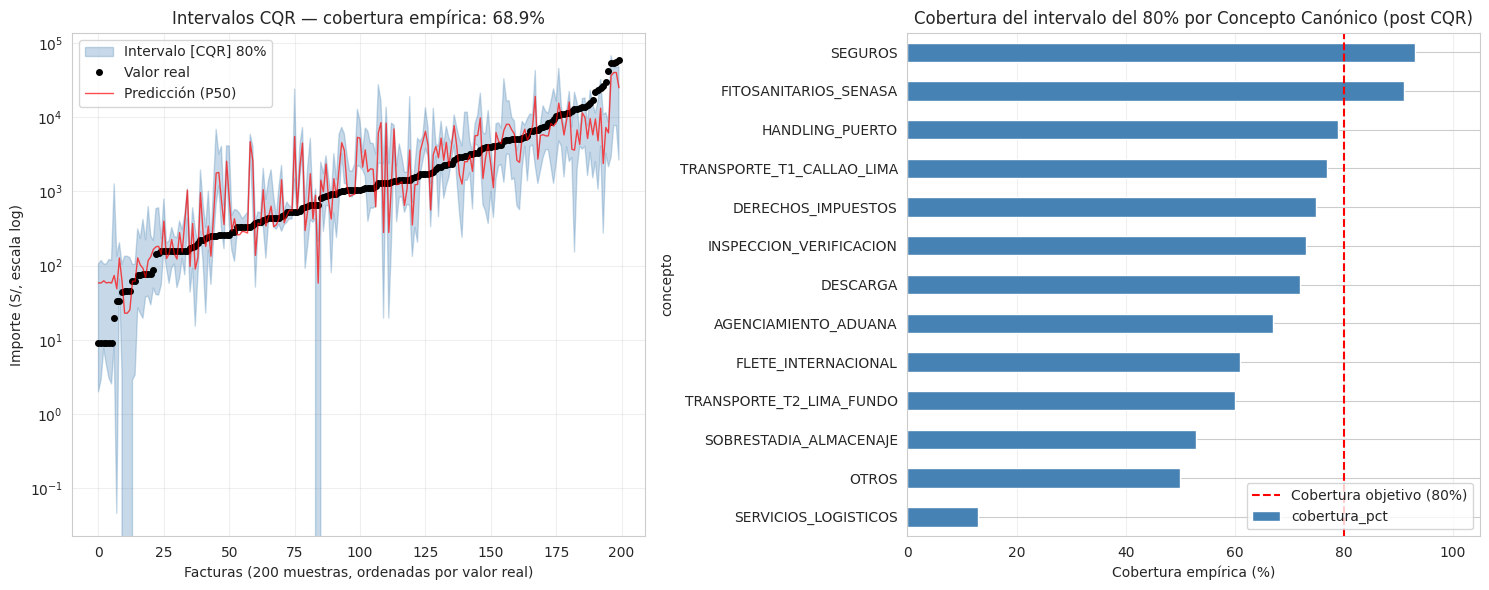


✓ Modelos CQR y calibración guardados en /content/drive/MyDrive/HortifrutCostosImport/models


In [20]:
# CELDA 19 — Conformalized Quantile Regression: calibrar los intervalos
# Esto va A REEMPLAZAR los resultados de las celdas 17/18.

# Dividir train aleatoriamente: 80% para entrenar cuantiles + 20% para calibración
np.random.seed(42)
n_total = len(X_train_clean)
idx = np.random.permutation(n_total)
n_tr  = int(0.8 * n_total)
idx_tr, idx_cal = idx[:n_tr], idx[n_tr:]

X_tr_cqr  = X_train_clean.iloc[idx_tr].reset_index(drop=True)
X_cal_cqr = X_train_clean.iloc[idx_cal].reset_index(drop=True)
y_tr_log  = y_train_log[idx_tr]
y_cal_log = y_train_log[idx_cal]
y_cal_pen = np.expm1(y_cal_log)

print(f"Train para cuantiles: {len(X_tr_cqr):,} filas")
print(f"Calibración:          {len(X_cal_cqr):,} filas")

# Re-entrenar P10, P50, P90 sobre 80% del train
print("\n⏳ Re-entrenando los 3 modelos de cuantiles...")
params_base = dict(n_estimators=500, learning_rate=0.05, num_leaves=63,
                   min_child_samples=20, random_state=42, n_jobs=-1, verbose=-1)
lgb_p10_cqr = lgb.LGBMRegressor(objective='quantile', alpha=0.10, **params_base).fit(X_tr_cqr, y_tr_log)
lgb_p50_cqr = lgb.LGBMRegressor(objective='quantile', alpha=0.50, **params_base).fit(X_tr_cqr, y_tr_log)
lgb_p90_cqr = lgb.LGBMRegressor(objective='quantile', alpha=0.90, **params_base).fit(X_tr_cqr, y_tr_log)
print("✓ Modelos re-entrenados")

# Predecir en set de calibración (en escala soles)
p10_cal = np.expm1(lgb_p10_cqr.predict(X_cal_cqr))
p90_cal = np.expm1(lgb_p90_cqr.predict(X_cal_cqr))

# Puntajes de no-conformidad: cuánto se escapó del intervalo (positivo = se escapó)
E_cal = np.maximum(p10_cal - y_cal_pen, y_cal_pen - p90_cal)

# Cuantil ajustado para garantizar cobertura del 80%
alpha = 0.20
n_cal = len(E_cal)
q_idx = np.ceil((n_cal + 1) * (1 - alpha)) / n_cal
Q_alpha = np.quantile(E_cal, min(q_idx, 1.0))

print(f"\n📊 Calibración:")
print(f"  Margen de ajuste (Q_alpha): S/ {Q_alpha:,.0f}")
print(f"  (Se agrega este margen a cada límite del intervalo)")

# Predecir en test con intervalos calibrados
p10_test = np.expm1(lgb_p10_cqr.predict(X_test_clean))
p50_test = np.expm1(lgb_p50_cqr.predict(X_test_clean))
p90_test = np.expm1(lgb_p90_cqr.predict(X_test_clean))

y_cqr_inf = np.maximum(p10_test - Q_alpha, 0)  # truncar a 0 (no hay montos negativos)
y_cqr_sup = p90_test + Q_alpha

# Evaluar cobertura empírica
dentro_cqr = (y_test_pen >= y_cqr_inf) & (y_test_pen <= y_cqr_sup)
cobertura_cqr = dentro_cqr.mean() * 100
ancho_mediano_cqr = np.median(y_cqr_sup - y_cqr_inf)
ancho_prom_cqr    = np.mean(y_cqr_sup - y_cqr_inf)

print(f"\n📊 Resultados con CQR:")
print(f"  Cobertura objetivo:        80.0%")
print(f"  Cobertura empírica (sin):  54.0%   ← Quantile Regression directa")
print(f"  Cobertura empírica (CQR):  {cobertura_cqr:.1f}%   ← Con calibración")
print(f"  Ancho mediano:             S/ {ancho_mediano_cqr:,.0f}")
print(f"  Ancho promedio:            S/ {ancho_prom_cqr:,.0f}")

# Cobertura por concepto canónico
df_cqr = pd.DataFrame({
    'concepto':  test['Concepto Canónico'].values,
    'real':      y_test_pen,
    'p50':       p50_test,
    'inf':       y_cqr_inf,
    'sup':       y_cqr_sup,
    'dentro':    dentro_cqr,
    'ancho':     y_cqr_sup - y_cqr_inf,
})
resumen_cqr = df_cqr.groupby('concepto').agg(
    n=('real', 'size'),
    cobertura_pct=('dentro', lambda s: s.mean()*100),
    ancho_mediano=('ancho', 'median'),
    real_mediano=('real', 'median'),
).round(0)
resumen_cqr['ancho_rel_%'] = (resumen_cqr['ancho_mediano'] / resumen_cqr['real_mediano'].replace(0, 1) * 100).round(1)
resumen_cqr = resumen_cqr.sort_values('cobertura_pct')
print(f"\n📋 Cobertura por concepto canónico tras CQR:")
print(resumen_cqr.to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sample_idx = np.random.choice(len(y_test_pen), 200, replace=False)
sample_idx.sort()
orden = np.argsort(y_test_pen[sample_idx])
xa = range(len(orden))

axes[0].fill_between(xa, y_cqr_inf[sample_idx][orden], y_cqr_sup[sample_idx][orden],
                     alpha=0.3, color='steelblue', label='Intervalo [CQR] 80%')
axes[0].plot(xa, y_test_pen[sample_idx][orden], 'o', color='black', markersize=4, label='Valor real')
axes[0].plot(xa, p50_test[sample_idx][orden], '-', color='red', linewidth=1, alpha=0.7, label='Predicción (P50)')
axes[0].set_yscale('log')
axes[0].set_xlabel('Facturas (200 muestras, ordenadas por valor real)')
axes[0].set_ylabel('Importe (S/, escala log)')
axes[0].set_title(f'Intervalos CQR — cobertura empírica: {cobertura_cqr:.1f}%')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.3)

resumen_cqr['cobertura_pct'].plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].axvline(80, color='red', linestyle='--', label='Cobertura objetivo (80%)')
axes[1].set_xlabel('Cobertura empírica (%)')
axes[1].set_title('Cobertura del intervalo del 80% por Concepto Canónico (post CQR)')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xlim([0, 105])

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/10_intervalos_cqr.png', dpi=100, bbox_inches='tight')
plt.show()

# Guardar
joblib.dump(lgb_p10_cqr, f'{MODELS_PATH}/lgb_quantile_p10_cqr.joblib')
joblib.dump(lgb_p50_cqr, f'{MODELS_PATH}/lgb_quantile_p50_cqr.joblib')
joblib.dump(lgb_p90_cqr, f'{MODELS_PATH}/lgb_quantile_p90_cqr.joblib')
joblib.dump({'Q_alpha': Q_alpha, 'alpha': alpha}, f'{MODELS_PATH}/cqr_calibration.joblib')
print(f"\n✓ Modelos CQR y calibración guardados en {MODELS_PATH}")

📊 Márgenes de ajuste por concepto canónico:
  SOBRESTADIA_ALMACENAJE        : S/    1,855
  DERECHOS_IMPUESTOS            : S/      800
  FLETE_INTERNACIONAL           : S/      611
  OTROS                         : S/      409
  SERVICIOS_LOGISTICOS          : S/      235
  DESCARGA                      : S/       52
  AGENCIAMIENTO_ADUANA          : S/       51
  TRANSPORTE_T2_LIMA_FUNDO      : S/       41
  SEGUROS                       : S/       29
  HANDLING_PUERTO               : S/       12
  INSPECCION_VERIFICACION       : S/       10
  FITOSANITARIOS_SENASA         : S/        0
  TRANSPORTE_T1_CALLAO_LIMA     : S/      -21
  GLOBAL (fallback)             : S/       42

📊 Resultados con CQR estratificado:
  Cobertura empírica (CQR global):       68.9%
  Cobertura empírica (CQR estratificado): 66.4%
  Ancho mediano:                          S/ 2,411

📋 Cobertura por concepto (post CQR estratificado):
                             n  cobertura_pct  ancho_mediano  real_mediano  a

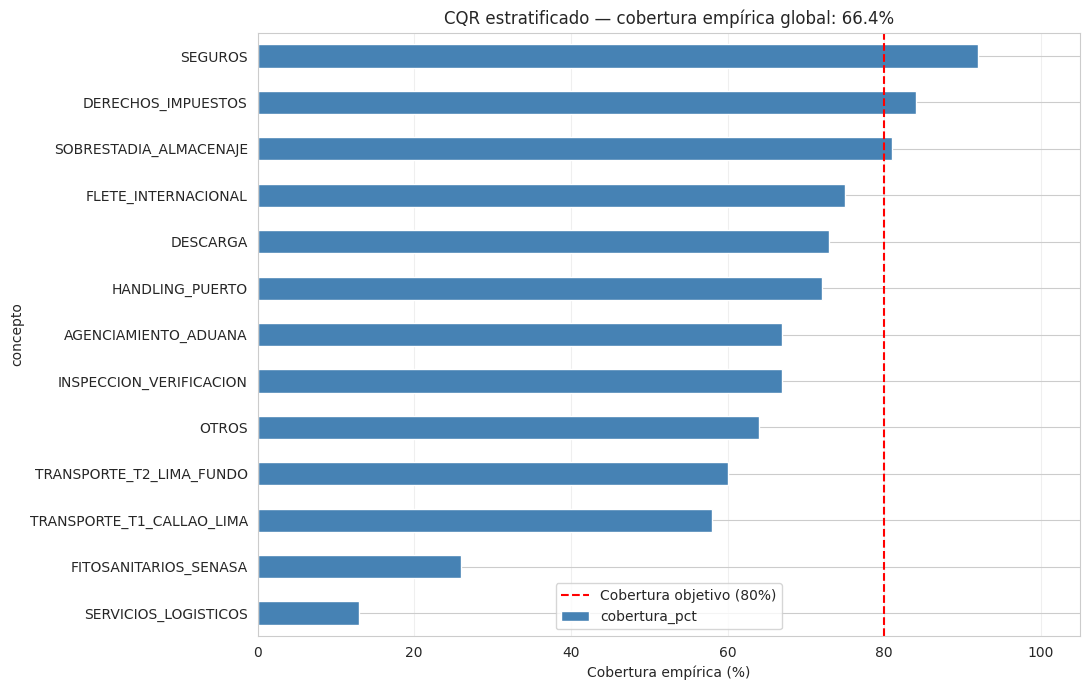


✓ Calibración estratificada guardada


In [21]:
# CELDA 20 — CQR estratificado: un margen de calibración por concepto canónico
# Reusamos los modelos lgb_p10_cqr, lgb_p50_cqr, lgb_p90_cqr ya entrenados.

# Predecir en calibración (escala soles) — ya lo hicimos pero recalculamos
p10_cal = np.expm1(lgb_p10_cqr.predict(X_cal_cqr))
p90_cal = np.expm1(lgb_p90_cqr.predict(X_cal_cqr))

# Construir DataFrame con las predicciones de calibración + concepto canónico
cal_df = pd.DataFrame({
    'concepto': train['Concepto Canónico'].values[idx_cal],
    'real':     y_cal_pen,
    'p10':      p10_cal,
    'p90':      p90_cal,
    'E':        np.maximum(p10_cal - y_cal_pen, y_cal_pen - p90_cal),
})

# Calcular un Q_alpha por concepto canónico
alpha = 0.20
Q_por_concepto = {}
for concepto, grupo in cal_df.groupby('concepto'):
    n_c = len(grupo)
    if n_c < 5:  # muy pocos casos, usar el global
        Q_por_concepto[concepto] = np.quantile(cal_df['E'], 1 - alpha)
    else:
        q_idx = min(np.ceil((n_c + 1) * (1 - alpha)) / n_c, 1.0)
        Q_por_concepto[concepto] = np.quantile(grupo['E'], q_idx)

# Margen global de fallback (para conceptos que aparezcan en test pero no en calibración)
Q_global = np.quantile(cal_df['E'], 1 - alpha)

print(f"📊 Márgenes de ajuste por concepto canónico:")
for concepto, q in sorted(Q_por_concepto.items(), key=lambda x: -x[1]):
    print(f"  {concepto:30}: S/ {q:>8,.0f}")
print(f"  {'GLOBAL (fallback)':30}: S/ {Q_global:>8,.0f}")

# Predecir en test
p10_test = np.expm1(lgb_p10_cqr.predict(X_test_clean))
p50_test = np.expm1(lgb_p50_cqr.predict(X_test_clean))
p90_test = np.expm1(lgb_p90_cqr.predict(X_test_clean))

# Asignar margen por concepto
conceptos_test = test['Concepto Canónico'].values
Q_test = np.array([Q_por_concepto.get(c, Q_global) for c in conceptos_test])

# Intervalo calibrado por concepto
y_strat_inf = np.maximum(p10_test - Q_test, 0)
y_strat_sup = p90_test + Q_test

# Cobertura
dentro_strat = (y_test_pen >= y_strat_inf) & (y_test_pen <= y_strat_sup)
cobertura_strat = dentro_strat.mean() * 100
ancho_mediano_strat = np.median(y_strat_sup - y_strat_inf)

print(f"\n📊 Resultados con CQR estratificado:")
print(f"  Cobertura empírica (CQR global):       68.9%")
print(f"  Cobertura empírica (CQR estratificado): {cobertura_strat:.1f}%")
print(f"  Ancho mediano:                          S/ {ancho_mediano_strat:,.0f}")

# Cobertura por concepto
df_strat = pd.DataFrame({
    'concepto':  conceptos_test,
    'real':      y_test_pen,
    'inf':       y_strat_inf,
    'sup':       y_strat_sup,
    'dentro':    dentro_strat,
    'ancho':     y_strat_sup - y_strat_inf,
})
resumen_strat = df_strat.groupby('concepto').agg(
    n=('real', 'size'),
    cobertura_pct=('dentro', lambda s: s.mean()*100),
    ancho_mediano=('ancho', 'median'),
    real_mediano=('real', 'median'),
).round(0)
resumen_strat['ancho_rel_%'] = (resumen_strat['ancho_mediano'] / resumen_strat['real_mediano'].replace(0, 1) * 100).round(1)
resumen_strat = resumen_strat.sort_values('cobertura_pct')

print(f"\n📋 Cobertura por concepto (post CQR estratificado):")
print(resumen_strat.to_string())

# Gráfico final
fig, ax = plt.subplots(figsize=(11, 7))
resumen_strat['cobertura_pct'].plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(80, color='red', linestyle='--', label='Cobertura objetivo (80%)')
ax.set_xlabel('Cobertura empírica (%)')
ax.set_title(f'CQR estratificado — cobertura empírica global: {cobertura_strat:.1f}%')
ax.legend()
ax.grid(axis='x', alpha=0.3)
ax.set_xlim([0, 105])
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/11_intervalos_cqr_estratificado.png', dpi=100, bbox_inches='tight')
plt.show()

# Guardar
joblib.dump(Q_por_concepto, f'{MODELS_PATH}/cqr_estratificado.joblib')
print(f"\n✓ Calibración estratificada guardada")